ielem_c = 0
R_left =
[[ 1.          0.5         0.          0.          0.        ]
 [ 0.          0.5         0.75        0.1875      0.        ]
 [ 0.          0.          0.25        0.6875      0.41666667]
 [-0.         -0.         -0.          0.125       0.52083333]
 [-0.         -0.         -0.          0.          0.0625    ]]
R_right =
[[ 0.5        -0.         -0.          0.          0.        ]
 [ 0.5         0.75        0.1875      0.          0.        ]
 [-0.          0.25        0.6875      0.41666667  0.08333333]
 [-0.         -0.          0.125       0.52083333  0.60416667]
 [-0.         -0.         -0.          0.0625      0.3125    ]]
R_loc =
[[ 1.          0.5         0.          0.          0.          0.        ]
 [ 0.          0.5         0.75        0.1875      0.          0.        ]
 [ 0.         -0.          0.25        0.6875      0.41666667  0.08333333]
 [ 0.         -0.         -0.          0.125       0.52083333  0.60416667]
 [ 0.         -0.         -0.

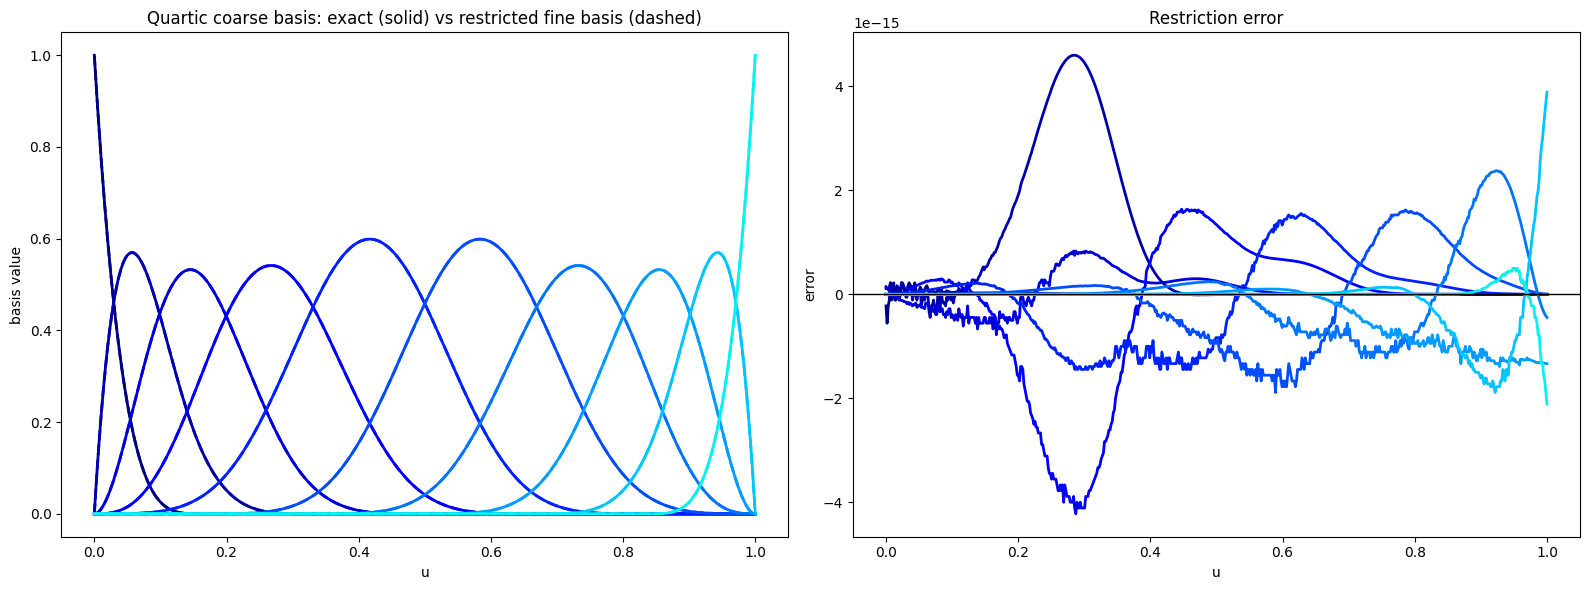

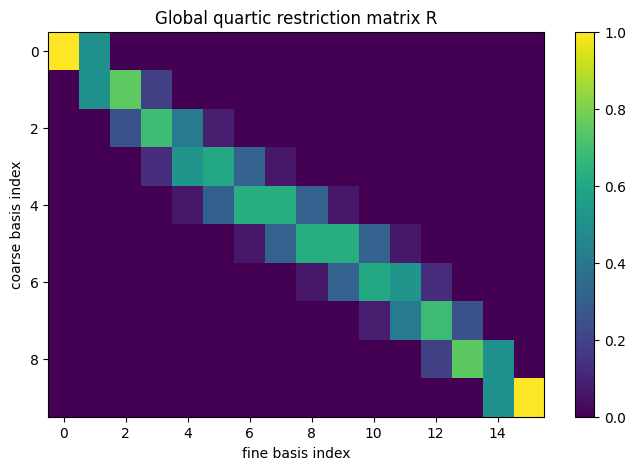

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from numpy.polynomial import Polynomial as Poly

# =========================================================
# quartic Bernstein basis
# =========================================================
def quartic_bernstein(xi):
    N = np.array([
        (1 - xi)**4,
        4*xi*(1 - xi)**3,
        6*xi**2*(1 - xi)**2,
        4*xi**3*(1 - xi),
        xi**4
    ])
    dN = np.array([
        -4*(1 - xi)**3,
        4*(1 - xi)**3 - 12*xi*(1 - xi)**2,
        12*xi*(1 - xi)**2 - 12*xi**2*(1 - xi),
        12*xi**2*(1 - xi) - 4*xi**3,
        4*xi**3
    ])
    return N, dN


# =========================================================
# quartic Bernstein -> IGA basis matrix for each element type
# =========================================================
def get_BtoN_matrix_p4(ielem, nxe):
    first_elem   = (ielem == 0)
    second_elem  = (ielem == 1)
    third_elem   = (ielem == 2)

    third_last   = (ielem == nxe - 3)
    second_last  = (ielem == nxe - 2)
    last_elem    = (ielem == nxe - 1)

    interior = not (first_elem or second_elem or third_elem or
                    third_last or second_last or last_elem)

    if first_elem:
        BtoN = np.array([
            [1.0,      0.0,      0.0,      0.0,      0.0],
            [0.0,      1.0,      0.5,      0.25,     0.125],
            [0.0,      0.0,      0.5,      7.0/12.0, 37.0/72.0],
            [0.0,      0.0,      0.0,      1.0/6.0,  23.0/72.0],
            [0.0,      0.0,      0.0,      0.0,      1.0/24.0],
        ])

    elif second_elem:
        BtoN = np.array([
            [1.0/8.0,  0.0,      0.0,      0.0,      0.0],
            [37.0/72.0,4.0/9.0,  2.0/9.0,  1.0/9.0,  1.0/18.0],
            [23.0/72.0,17.0/36.0,11.0/18.0,5.0/9.0,  4.0/9.0],
            [1.0/24.0, 1.0/12.0, 1.0/6.0,  1.0/3.0,  11.0/24.0],
            [0.0,      0.0,      0.0,      0.0,      1.0/24.0],
        ])

    elif third_elem:
        BtoN = np.array([
            [1.0/18.0, 0.0,      0.0,      0.0,      0.0],
            [4.0/9.0,  1.0/3.0,  1.0/6.0,  1.0/12.0, 1.0/24.0],
            [11.0/24.0,7.0/12.0, 2.0/3.0,  7.0/12.0, 11.0/24.0],
            [1.0/24.0, 1.0/12.0, 1.0/6.0,  1.0/3.0,  11.0/24.0],
            [0.0,      0.0,      0.0,      0.0,      1.0/24.0],
        ])

    elif third_last:
        BtoN = np.array([
            [1.0/24.0, 0.0,      0.0,      0.0,      0.0],
            [11.0/24.0,1.0/3.0,  1.0/6.0,  1.0/12.0, 1.0/24.0],
            [11.0/24.0,7.0/12.0, 2.0/3.0,  7.0/12.0, 11.0/24.0],
            [1.0/24.0, 1.0/12.0, 1.0/6.0,  1.0/3.0,  4.0/9.0],
            [0.0,      0.0,      0.0,      0.0,      1.0/18.0],
        ])

    elif second_last:
        BtoN = np.array([
            [1.0/24.0, 0.0,      0.0,      0.0,      0.0],
            [11.0/24.0,1.0/3.0,  1.0/6.0,  1.0/12.0, 1.0/24.0],
            [4.0/9.0,  5.0/9.0,  11.0/18.0,17.0/36.0,23.0/72.0],
            [1.0/18.0, 1.0/9.0,  2.0/9.0,  4.0/9.0,  37.0/72.0],
            [0.0,      0.0,      0.0,      0.0,      1.0/8.0],
        ])

    elif last_elem:
        BtoN = np.array([
            [1.0/24.0, 0.0,      0.0,      0.0,      0.0],
            [23.0/72.0,1.0/6.0,  0.0,      0.0,      0.0],
            [37.0/72.0,7.0/12.0, 0.5,      0.0,      0.0],
            [0.125,    0.25,     0.5,      1.0,      0.0],
            [0.0,      0.0,      0.0,      0.0,      1.0],
        ])

    else:  # interior
        BtoN = np.array([
            [1.0/24.0, 0.0,      0.0,      0.0,      0.0],
            [11.0/24.0,1.0/3.0,  1.0/6.0,  1.0/12.0, 1.0/24.0],
            [11.0/24.0,7.0/12.0, 2.0/3.0,  7.0/12.0, 11.0/24.0],
            [1.0/24.0, 1.0/12.0, 1.0/6.0,  1.0/3.0,  11.0/24.0],
            [0.0,      0.0,      0.0,      0.0,      1.0/24.0],
        ])

    return BtoN


# =========================================================
# build quartic global basis from explicit element formulas
# =========================================================
def build_basis_p4(nxe, u):
    p = 4
    knots = [0.0]*(p+1) + [i/nxe for i in range(1, nxe)] + [1.0]*(p+1)
    nglob = nxe + p

    global_basis = np.zeros((nglob, u.shape[0]))
    elem_conn = [[i, i+1, i+2, i+3, i+4] for i in range(nxe)]

    for ielem in range(nxe):
        knot1, knot2 = knots[p + ielem], knots[p + ielem + 1]
        xi = (u - knot1) / (knot2 - knot1)
        xi_mask = np.logical_and(xi >= 0.0, xi <= 1.0)

        B, dB = quartic_bernstein(xi)
        BtoN = get_BtoN_matrix_p4(ielem, nxe)
        Nloc = BtoN @ B

        g0, g1, g2, g3, g4 = elem_conn[ielem]
        global_basis[g0] += Nloc[0] * xi_mask
        global_basis[g1] += Nloc[1] * xi_mask
        global_basis[g2] += Nloc[2] * xi_mask
        global_basis[g3] += Nloc[3] * xi_mask
        global_basis[g4] += Nloc[4] * xi_mask

    return global_basis


# =========================================================
# Bernstein basis expressed in power basis after substitution
# returns matrix M such that:
#   B_sub(xi) = M @ [1, xi, xi^2, ..., xi^p]
# =========================================================
def bernstein_to_power_matrix_subst(p, a, b):
    M = np.zeros((p+1, p+1))

    x = Poly([0.0, 1.0])        # x
    t = Poly([b, a])            # a*x + b

    for i in range(p+1):
        poly = comb(p, i) * (t**i) * ((1 - t)**(p - i))
        coef = poly.coef
        M[i, :len(coef)] = coef

    return M


# =========================================================
# local restriction stencil for one coarse element
# quartic p=4, h-ref factor 2
# coarse local size = 5
# union of two fine children = 6 fine basis functions
# =========================================================
def build_local_restriction_matrix_p4(ielem_c, nxe_c):
    p = 4

    BtoN_c  = get_BtoN_matrix_p4(ielem_c, nxe_c)
    BtoN_Lf = get_BtoN_matrix_p4(2*ielem_c,   2*nxe_c)
    BtoN_Rf = get_BtoN_matrix_p4(2*ielem_c+1, 2*nxe_c)

    # Bernstein -> power basis matrices
    Bc   = bernstein_to_power_matrix_subst(p, a=1.0, b=0.0)   # xi_f = xi
    B_Lf = bernstein_to_power_matrix_subst(p, a=2.0, b=0.0)   # xi_f = 2 xi
    B_Rf = bernstein_to_power_matrix_subst(p, a=2.0, b=-1.0)  # xi_f = 2 xi - 1

    # coarse basis in power basis
    N_H  = BtoN_c  @ Bc
    N_Lh = BtoN_Lf @ B_Lf
    N_Rh = BtoN_Rf @ B_Rf

    # left and right child restriction in local basis
    R_left_basis  = np.linalg.solve(N_Lh.T, N_H.T).T
    R_right_basis = np.linalg.solve(N_Rh.T, N_H.T).T

    # assemble local stencil: (5 coarse) x (6 fine-union)
    R = np.zeros((5, 6))
    R[:, :5] += R_left_basis
    R[:, 1:] += R_right_basis

    # same normalization idea as your cubic script
    R /= np.sum(R, axis=0, keepdims=True)

    return R_left_basis, R_right_basis, R


# =========================================================
# build global restriction matrix
# =========================================================
def restriction_p4_h2(nxe_f):
    p = 4
    assert nxe_f % 2 == 0

    nxe_c = nxe_f // 2
    n_fine = nxe_f + p
    n_coarse = nxe_c + p

    R = np.zeros((n_coarse, n_fine))

    for ielem in range(nxe_c):
        _, _, R_loc = build_local_restriction_matrix_p4(ielem, nxe_c)

        # coarse rows [ielem : ielem+5]
        # fine cols   [2*ielem : 2*ielem+6]
        R[ielem:(ielem+5), 2*ielem:(2*ielem+6)] += R_loc

    R /= np.sum(R, axis=0, keepdims=True)
    return R


# =========================================================
# print local stencils for nxe_c = 6
# =========================================================
nxe_c = 6
for ielem in range(nxe_c):
    R_left, R_right, R_loc = build_local_restriction_matrix_p4(ielem, nxe_c)
    print(f"ielem_c = {ielem}")
    print("R_left =")
    print(np.round(R_left, 12))
    print("R_right =")
    print(np.round(R_right, 12))
    print("R_loc =")
    print(np.round(R_loc, 12))
    print("="*80)


# =========================================================
# verify globally by plotting
# =========================================================
u = np.linspace(0.0, 1.0, 600)

nxe_f = 12          # choose even; gives nxe_c = 6
nxe_c = nxe_f // 2
p = 4

n_fine   = nxe_f + p
n_coarse = nxe_c + p

fine_basis   = build_basis_p4(nxe_f, u)
coarse_basis = build_basis_p4(nxe_c, u)

R = restriction_p4_h2(nxe_f)
coarse_basis_from_restriction = R @ fine_basis

colors = plt.cm.jet(np.linspace(0.0, 1.0, n_fine + n_coarse))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------
# panel 1: exact coarse basis vs restricted fine basis
# -------------------------------------------------
for i in range(n_coarse):
    ax[0].plot(u, coarse_basis[i], color=colors[i], lw=2)
    ax[0].plot(u, coarse_basis_from_restriction[i], '--', color=colors[i], lw=2)

ax[0].set_title("Quartic coarse basis: exact (solid) vs restricted fine basis (dashed)")
ax[0].set_xlabel("u")
ax[0].set_ylabel("basis value")

# -------------------------------------------------
# panel 2: pointwise error
# -------------------------------------------------
err = coarse_basis_from_restriction - coarse_basis
for i in range(n_coarse):
    ax[1].plot(u, err[i], color=colors[i], lw=2)

ax[1].axhline(0.0, color='k', lw=1)
ax[1].set_title("Restriction error")
ax[1].set_xlabel("u")
ax[1].set_ylabel("error")

plt.tight_layout()
plt.show()


# =========================================================
# optional: visualize global R
# =========================================================
plt.figure(figsize=(8, 5))
plt.imshow(R, aspect='auto')
plt.colorbar()
plt.title("Global quartic restriction matrix R")
plt.xlabel("fine basis index")
plt.ylabel("coarse basis index")
plt.show()